In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import geopandas as gpd

In [3]:
# read the dataet

df = pd.read_csv("C:/Users/ASUS/ERIA_Dataset_2.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2801 entries, 0 to 2800
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country_name                 2801 non-null   object 
 1   country_code                 2757 non-null   object 
 2   year                         2801 non-null   int64  
 3   gdp_growth_pct               2796 non-null   float64
 4   gdp_per_capita               2785 non-null   float64
 5   trade_openness_pct           2421 non-null   float64
 6   investment_pct_gdp           2322 non-null   float64
 7   population_total             2757 non-null   float64
 8   gini_index                   784 non-null    float64
 9   secure_servers_per_million   2725 non-null   float64
 10  corruption_control_score     1795 non-null   object 
 11  education_index              1819 non-null   float64
 12  income_index                 1819 non-null   float64
 13  cybersecurity_inde

In [7]:
## fill the missing values for numerical values (float64)

from sklearn.impute import KNNImputer
impute = KNNImputer()

for i in df.select_dtypes(include = "number").columns:
    df[i] = impute.fit_transform(df[[i]])

In [9]:
df.isnull().sum()

country_name                      0
country_code                     44
year                              0
gdp_growth_pct                    0
gdp_per_capita                    0
trade_openness_pct                0
investment_pct_gdp                0
population_total                  0
gini_index                        0
secure_servers_per_million        0
corruption_control_score       1006
education_index                   0
income_index                      0
cybersecurity_index               0
mobile_broadband_traffic_pb       0
cyber_incident_count              0
fixed_broadband_subs              0
secure_servers_per_capita         0
dtype: int64

In [11]:
workdata = df.drop(df.index[:44])

In [12]:
workdata

,country_name,country_code,year,gdp_growth_pct,gdp_per_capita,trade_openness_pct,investment_pct_gdp,population_total,gini_index,secure_servers_per_million,corruption_control_score,education_index,income_index,cybersecurity_index,mobile_broadband_traffic_pb,cyber_incident_count,fixed_broadband_subs,secure_servers_per_capita
44,Aruba,ABW,2014.0,-1.586575,27914.843340,162.882052,23.111461,106807.0,35.720026,552.398251,1.014001012,0.661865,0.709481,50.397965,115.146555,17.076642,18.573500,0.000552
45,Aruba,ABW,2015.0,-0.623626,27458.225330,145.833663,21.538920,107906.0,35.720026,732.118696,1.248301148,0.661865,0.709481,50.397965,115.146555,17.076642,18.237000,0.000732
46,Aruba,ABW,2016.0,1.719625,27719.500730,142.239763,20.575010,108727.0,35.720026,1131.273741,1.232693315,0.661865,0.709481,50.397965,115.146555,17.076642,15.646083,0.001131
47,Aruba,ABW,2017.0,7.048533,29671.135830,143.804295,20.551182,108735.0,35.720026,947.257093,NaN,0.661865,0.709481,50.397965,115.146555,17.076642,15.646083,0.000947
48,Aruba,ABW,2018.0,2.397086,30334.116220,145.213552,22.401724,108908.0,35.720026,1120.211555,1.207401395,0.661865,0.709481,50.397965,115.146555,17.076642,15.646083,0.001120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2796,Zimbabwe,ZWE,2020.0,-7.816933,1230.191557,47.313382,13.146075,15526888.0,35.720026,71.295678,-1.308787823,0.600000,0.448000,50.397965,5.610000,17.076642,1.310380,0.000071
2797,Zimbabwe,ZWE,2021.0,8.468039,1311.531000,50.847123,15.507058,15797210.0,35.720026,75.899478,-1.277147293,0.600000,0.456000,36.500000,10.309000,17.076642,1.299810,0.000076
2798,Zimbabwe,ZWE,2022.0,6.139176,1368.498418,64.763607,14.610339,16069056.0,35.720026,78.100419,-1.259969473,0.600000,0.458000,50.397965,11.713400,17.076642,1.621500,0.000078
2799,Zimbabwe,ZWE,2023.0,5.336770,1417.557759,50.794964,16.274040,16340822.0,35.720026,89.346791,-1.261216044,0.600000,0.460000,50.397965,15.604600,17.076642,1.574580,0.000089


In [13]:
## to see each country name listed

workdata["country_name"].unique()

array(['Aruba', 'Africa Eastern and Southern', 'Afghanistan',
       'Africa Western and Central', 'Angola', 'Albania', 'Andorra',
       'Arab World', 'United Arab Emirates', 'Argentina', 'Armenia',
       'American Samoa', 'Antigua and Barbuda', 'Australia', 'Austria',
       'Azerbaijan', 'Burundi', 'Belgium', 'Benin', 'Burkina Faso',
       'Bangladesh', 'Bulgaria', 'Bahrain', 'Bahamas, The',
       'Bosnia and Herzegovina', 'Belarus', 'Belize', 'Bermuda',
       'Bolivia', 'Brazil', 'Barbados', 'Brunei Darussalam', 'Bhutan',
       'Botswana', 'Central African Republic', 'Canada',
       'Central Europe and the Baltics', 'Switzerland', 'Channel Islands',
       'Chile', 'China', "Cote d'Ivoire", 'Cameroon', 'Congo, Dem. Rep.',
       'Congo, Rep.', 'Colombia', 'Comoros', 'Cabo Verde', 'Costa Rica',
       'Caribbean small states', 'Cuba', 'Curacao', 'Cayman Islands',
       'Cyprus', 'Czechia', 'Germany', 'Djibouti', 'Dominica', 'Denmark',
       'Dominican Republic', 'Algeria',
 

In [50]:
workdata = workdata.rename(columns={
    'gdp_growth_pct': 'GDP Growth',
    'trade_openness_pct': 'Trade Openness',
    'secure_servers_per_million': 'Secure Servers per Million',
    'country_name': 'Country',
    'population_total': 'Population Total',
    'gdp_per_capita': 'GDP per Capita'
})

In [51]:
# filter year 2024

sea_2024 = workdata[workdata['year'] == 2024].copy()

In [52]:
sea_countries = [
    'Indonesia',
    'Thailand',
    'Malaysia',
    'Brunei Darussalam',
    'Singapore',
    'Viet Nam',
    'Cambodia',
    'Lao PDR',
    'Timor-Leste',
    'Philippines'
]

In [53]:
sea_2024 = sea_2024[sea_2024['Country'].isin(sea_countries)]

In [64]:
sea_2024.head(20)

,Country,country_code,year,GDP Growth,GDP per Capita,Trade Openness,investment_pct_gdp,Population Total,gini_index,Secure Servers per Million,corruption_control_score,education_index,income_index,cybersecurity_index,mobile_broadband_traffic_pb,cyber_incident_count,fixed_broadband_subs,secure_servers_per_capita
391,Brunei Darussalam,BRN,2024.0,4.200373,29605.877610,133.223219,28.362368,462721.0,35.720026,16128.509400,NaN,0.661865,0.709481,70.4,102.586000,17.076642,21.177100,0.016129
1174,Indonesia,IDN,2024.0,5.030345,4367.862666,42.572647,31.396354,283487931.0,34.900000,2939.490218,NaN,0.661865,0.709481,100.0,126.271000,3.000000,4.921970,0.002939
1348,Cambodia,KHM,2024.0,6.015815,2183.556824,143.447010,32.186132,17638801.0,35.720026,817.289112,NaN,0.661865,0.709481,37.1,259.747000,17.076642,4.145660,0.000817
1413,Lao PDR,LAO,2024.0,4.258257,2724.424627,85.880548,24.667327,7769819.0,35.720026,301.680129,NaN,0.661865,0.709481,33.7,115.146555,17.076642,15.646083,0.000302
1813,Malaysia,MYS,2024.0,5.114155,11868.364740,137.366341,21.852583,35557673.0,35.720026,7475.461063,NaN,0.661865,0.709481,98.8,347.231000,2.000000,13.546400,0.007475
2009,Philippines,PHL,2024.0,5.692016,3925.304870,65.885473,23.684645,115843670.0,35.720026,131.556606,NaN,0.661865,0.709481,93.5,127.344000,6.000000,7.138930,0.000132
2227,Singapore,SGP,2024.0,4.388024,67706.833610,322.371428,22.200258,6036860.0,35.720026,209665.455200,NaN,0.661865,0.709481,99.9,110.434000,12.000000,27.813700,0.209665
2490,Thailand,THA,2024.0,2.525962,6573.444300,136.774745,21.572276,71668011.0,35.720026,3149.996726,NaN,0.661865,0.709481,99.2,345.298000,14.000000,14.887000,0.003150
2534,Timor-Leste,TLS,2024.0,-2.189122,1235.834110,85.880548,24.667327,1400638.0,35.720026,264.879291,NaN,0.661865,0.709481,16.8,115.146555,17.076642,0.005997,0.000265
2718,Viet Nam,VNM,2024.0,7.091187,4017.746041,85.880548,24.667327,100987686.0,35.720026,5733.748568,NaN,0.661865,0.709481,99.7,128.383000,2.000000,23.711300,0.005734


In [58]:
sea_2024.isnull().sum()

Country                         0
country_code                    0
year                            0
GDP Growth                      0
GDP per Capita                  0
Trade Openness                  0
investment_pct_gdp              0
Population Total                0
gini_index                      0
Secure Servers per Million      0
corruption_control_score       10
education_index                 0
income_index                    0
cybersecurity_index             0
mobile_broadband_traffic_pb     0
cyber_incident_count            0
fixed_broadband_subs            0
secure_servers_per_capita       0
dtype: int64

In [59]:
## load the geometry

import geopandas as gpd

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

In [65]:
## merge the data

sea_2024["Country"] = sea_2024["Country"].replace({
    "Viet Nam": "Vietnam",
    "Lao PDR": "Laos",
    "Brunei Darussalam": "Brunei"
})


sea_map = world.merge(
    sea_2024,
    left_on = "ADMIN",
    right_on = "Country",
    how = "inner"
)

In [66]:
## check

print(sea_2024["Country"].unique())

['Brunei' 'Indonesia' 'Cambodia' 'Laos' 'Malaysia' 'Philippines'
 'Singapore' 'Thailand' 'Timor-Leste' 'Vietnam']


In [67]:
## define the SEA bounding box

sea_bounds = (90, -15, 150, 25)

sea_map_clipped = sea_map.cx[
    sea_bounds[0]: sea_bounds[2],
    sea_bounds[1]: sea_bounds[3]
]

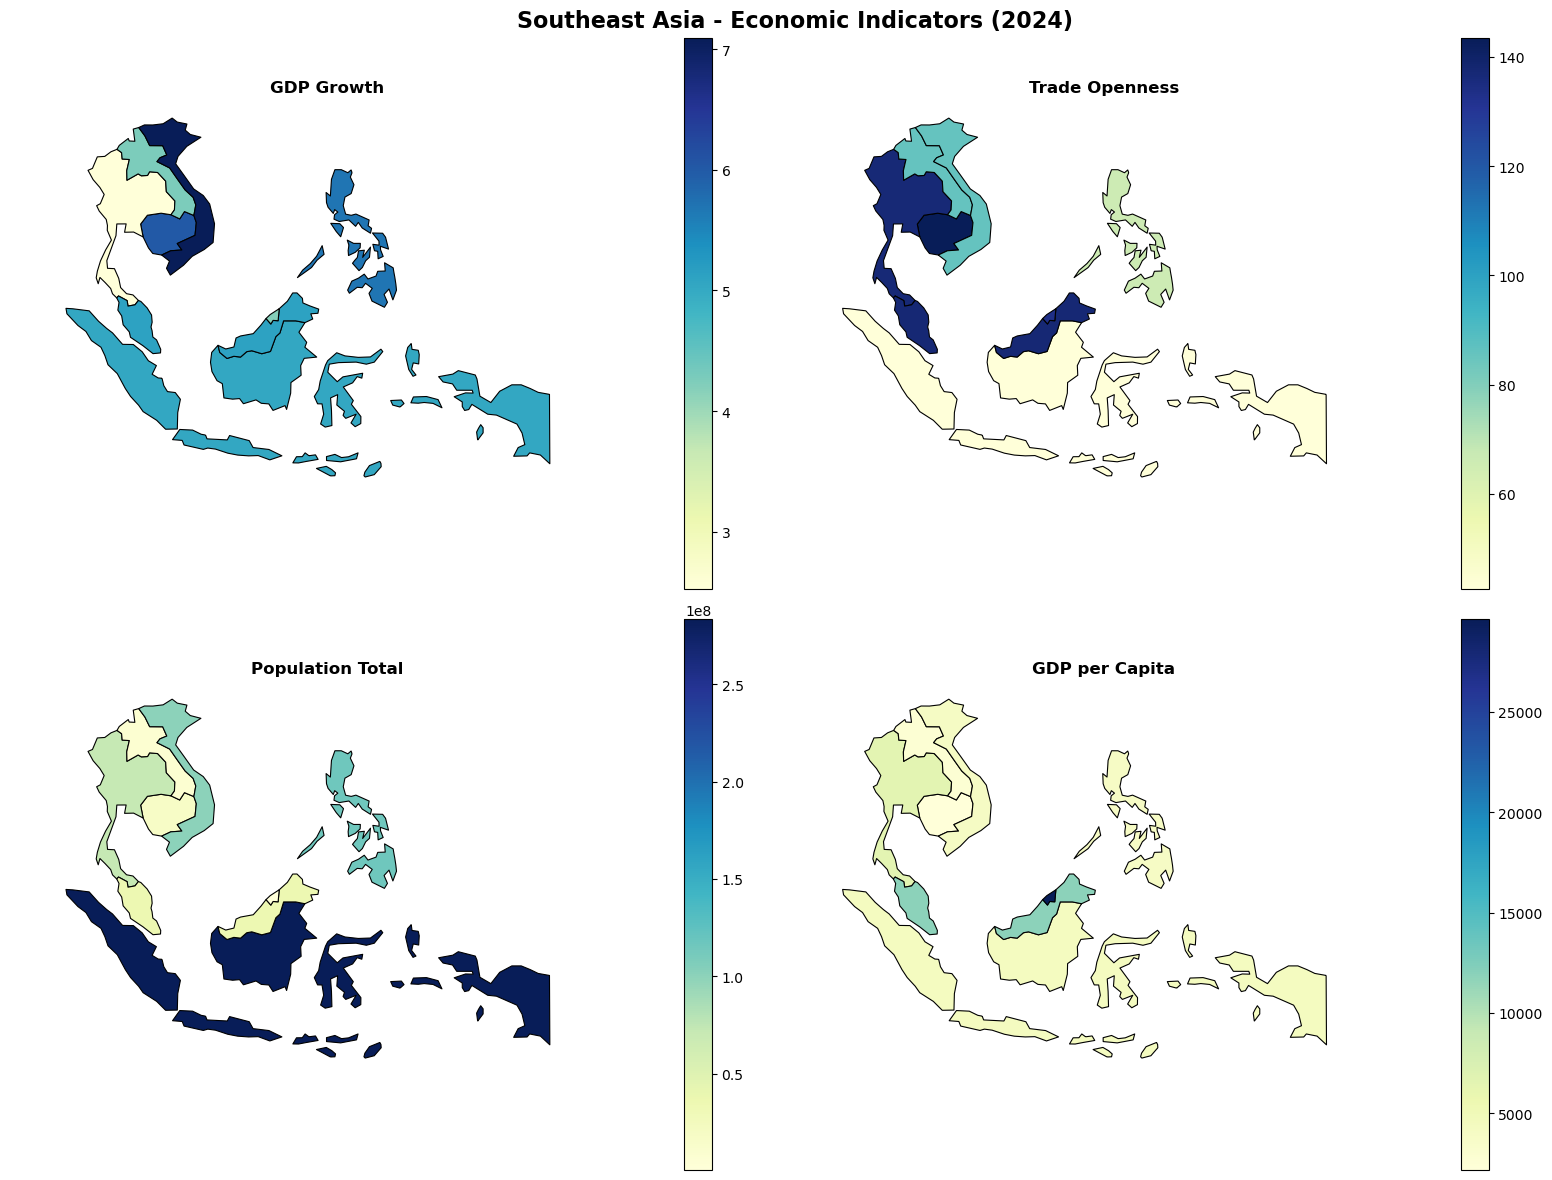

In [68]:
## plot SEA geopmas

fig, axes = plt.subplots(2, 2, figsize = (16, 12))

indicators = [
    "GDP Growth",
    "Trade Openness",
    "Population Total",
    "GDP per Capita"
]

for ax, indicator in zip(axes.flatten(), indicators):
    
    sea_map_clipped.plot(
        column = indicator,
        cmap = "YlGnBu",
        linewidth = 0.8,
        edgecolor = "black",
        legend = True,
        ax = ax
    )
    
    ax.set_title(indicator, fontsize = 12, fontweight = "bold")
    ax.set_xlim(90, 150)
    ax.set_ylim(-15, 25)
    ax.axis("off")
    
plt.suptitle(
    "Southeast Asia - Economic Indicators (2024)",
    fontsize = 16,
    fontweight = "bold"
)

plt.tight_layout()
plt.show()